<a href="https://colab.research.google.com/github/amber-pan/Self-taught-AI-Engineer/blob/main/MSAIMLincrementalCapstone7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project — Clustering Credit Card Users with PCA and K-Means

Task: Cluster the credit card users into different groups to find any meaningful patterns. Use Principal Component Analysis (PCA) to reduce the dimension of the feature space and then use the K-means algorithm to find clusters. Import relevant Python libraries.


# Dataset Information

Dataset used: `CC GENERAL.csv`

The dataset contains customer credit card usage information.

## Important Variables

| Variable                         | Description                                |
| -------------------------------- | ------------------------------------------ |
| CUST_ID                          | Identification of credit card holder       |
| BALANCE                          | Balance amount left in account             |
| BALANCE_FREQUENCY                | Frequency of balance updates               |
| PURCHASES                        | Number of purchases made                   |
| ONEOFF_PURCHASES                 | Maximum purchase amount in one transaction |
| INSTALLMENTS_PURCHASES           | Purchases made in installments             |
| CASH_ADVANCE                     | Cash advance amount                        |
| PURCHASES_FREQUENCY              | Frequency of purchases                     |
| ONEOFF_PURCHASES_FREQUENCY       | Frequency of one-time purchases            |
| PURCHASES_INSTALLMENTS_FREQUENCY | Frequency of installment purchases         |
| CASH_ADVANCE_FREQUENCY           | Frequency of cash advances                 |
| CASH_ADVANCE_TRX                 | Number of cash advance transactions        |
| PURCHASES_TRX                    | Number of purchase transactions            |
| CREDIT_LIMIT                     | Credit card limit                          |
| PAYMENTS                         | Total payments made                        |
| MINIMUM_PAYMENTS                 | Minimum payments made                      |
| PRC_FULL_PAYMENT                 | Percentage of full payment                 |
| TENURE                           | Credit card service tenure                 |



# Project Requirements

## Step 1 — Import Required Libraries

Import all necessary Python libraries for:

* Data manipulation
* Data visualization
* Data preprocessing
* PCA
* K-Means clustering

Libraries may include:

* pandas
* numpy
* matplotlib
* seaborn
* sklearn

## Step 2 — Load the Dataset

Load the dataset `CC GENERAL.csv` into a pandas DataFrame.

* Display the first few rows
* Check dataset shape
* Display dataset information


## Step 3 — Check for Missing Values

Identify null or missing values in the dataset.

* Use `.isnull().sum()`
* Analyze which columns contain missing values


## Step 4 — Handle Missing Values

Clean the dataset before analysis.

* Remove unnecessary columns such as customer ID
* Fill missing values using appropriate techniques such as:

  * Mean imputation
  * Median imputation


## Step 5 — Perform Feature Scaling

Standardize the dataset before applying PCA.

* Use `StandardScaler`
* Transform all numerical features
* Convert scaled output back to a DataFrame if needed


## Step 6 — Perform PCA Using All Features

Apply Principal Component Analysis using all available features.

* Fit PCA on scaled data
* Compute explained variance ratio
* Compute cumulative explained variance

## Step 7 — Plot PCA Explained Variance

Create a graph to visualize cumulative explained variance.

* Plot:

  * X-axis → Number of Principal Components
  * Y-axis → Cumulative Explained Variance
* Draw a horizontal reference line at 85% variance

Goal:

* Identify the number of principal components required to explain at least 85% of the variance


## Step 8 — Determine Components Covering 85% Variance

Identify the minimum number of components needed to retain 85% information from the original dataset.

* Use cumulative explained variance values
* Print the required number of components


## Step 9 — Perform PCA with 2 Components

Reduce the dataset into two principal components.

* Apply PCA with `n_components=2`
* Transform scaled data
* Store results in a new DataFrame

---

## Step 10 — Visualize PCA Components

Create a 2D scatter plot of the transformed PCA data.


* Plot:

  * Principal Component 1
  * Principal Component 2
* Label axes and title

Purpose:

* Observe overall data distribution

---

## Step 11 — Compute Covariance Matrix

Generate the covariance matrix from PCA-transformed features.

Tasks:

* Calculate covariance matrix
* Convert into a readable DataFrame


## Step 12 — Identify Features with Highest Covariance

Find the two variables that have the strongest covariance relationship.

* Remove diagonal covariance values
* Find highest covariance pair
* Print:

  * Variable names
  * Covariance value


## Step 13 — Determine Optimal Number of Clusters

Use the Elbow Method to determine the ideal number of clusters.

* Train K-Means models for multiple cluster values
* Store WCSS (Within-Cluster Sum of Squares)
* Plot elbow graph

Graph:

* X-axis → Number of Clusters
* Y-axis → WCSS

---

## Step 14 — Apply K-Means Clustering

Train the final K-Means clustering model.

* Choose optimal cluster count from elbow graph
* Fit K-Means model on PCA-transformed data
* Generate cluster labels



## Step 15 — Visualize Clusters

Visualize clustered customers in 2D PCA space.

* Create scatter plot
* Use different colors for clusters
* Display cluster centroids

Purpose:

* Understand customer segmentation patterns





## Step 1 — Import Required Libraries and
## Step 2 — Load the Dataset

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

if not os.path.ismount('/content/drive'):
  drive.mount('/content/drive')


df_credit_card=pd.read_csv('/content/drive/MyDrive/Colab Data/CC GENERAL.csv')

In [ ]:
df_credit_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df_credit_card.head(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df_credit_card.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Step 3 — Check for Missing Values

In [ ]:
#check nulls
df_credit_card.isna().sum()


,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


## Step 4 — Handle Missing Values

In [ ]:
#replace NaN with mean
df_credit_card['MINIMUM_PAYMENTS'] = df_credit_card['MINIMUM_PAYMENTS'].fillna(df_credit_card['MINIMUM_PAYMENTS'].mean())
df_credit_card['CREDIT_LIMIT'] = df_credit_card['CREDIT_LIMIT'].fillna(df_credit_card['CREDIT_LIMIT'].mean())


#Remove cust_id columns, since it is not necesary
df_credit_card = df_credit_card.drop(columns=['CUST_ID'])


In [ ]:
#check nulls
df_credit_card.isna().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Step 5 — Perform Feature Scaling

In [ ]:
# Standardize the feature variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_credit_card)

X_scaled_df = pd.DataFrame(X_scaled, columns=df_credit_card.columns)



## Step 6 — Perform PCA Using All Features
## Step 7 — Plot PCA Explained Variance
## Step 8 — Determine Components Covering 85% Variance


Explained variance ratio for each component:
[2.72900372e-01 2.03019913e-01 8.79197945e-02 7.47997502e-02
 6.26279204e-02 5.75021129e-02 4.88723464e-02 4.25748554e-02
 3.82880445e-02 3.08000623e-02 2.37189739e-02 1.77363237e-02
 1.42649185e-02 1.21736915e-02 1.01298988e-02 2.67033632e-03
 6.85223491e-07]

Cumulative explained variance for each component:
[0.27290037 0.47592029 0.56384008 0.63863983 0.70126775 0.75876986
 0.80764221 0.85021707 0.88850511 0.91930517 0.94302415 0.96076047
 0.97502539 0.98719908 0.99732898 0.99999931 1.        ]


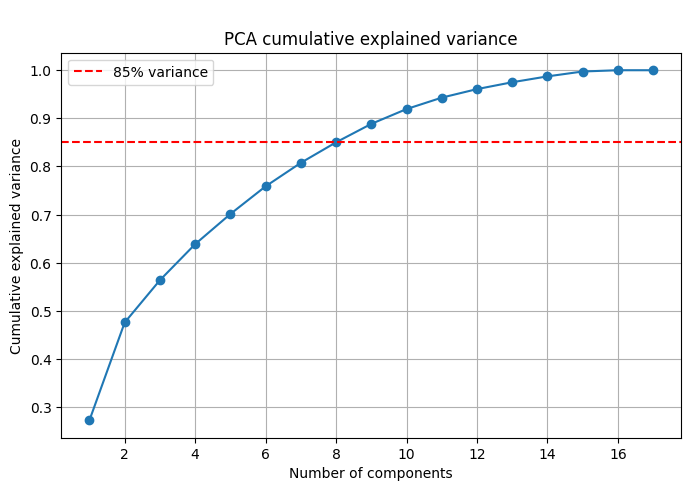

Components needed for 85% variance: 8


In [ ]:
#Fit PCA on scaled data

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled_df)


#Compute explained variance ratio
#Compute cumulative explained variance

exp_variance=0.85

explained_var_ratio = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_var_ratio)

print('\nExplained variance ratio for each component:')
print(explained_var_ratio)
print('\nCumulative explained variance for each component:')
print(cum_explained)

####
"""
Create a graph to visualize cumulative explained variance.

* Plot:

  * X-axis → Number of Principal Components
  * Y-axis → Cumulative Explained Variance
* Draw a horizontal reference line at 85% variance
"""
####
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker='o')
plt.axhline(exp_variance, color='r', linestyle='--', label='85% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('\nPCA cumulative explained variance')
plt.legend()
plt.grid(True)
plt.show()


###
"""
Identify the minimum number of components needed to retain 85% information from the original dataset.

* Use cumulative explained variance values
* Print the required number of components to reach 85%
"""
###
n_components_85 = np.argmax(cum_explained >= exp_variance) + 1
print('Components needed for 85% variance:', n_components_85)


## Step 9 — Perform PCA with 2 Components

In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])
pca_df.head()


,PC1,PC2
0,-1.682220,-1.076451
1,-1.138295,2.506477
2,0.969684,-0.383520
3,-0.873628,0.043166
4,-1.599434,-0.688581


## Step 10 — Visualize PCA Components

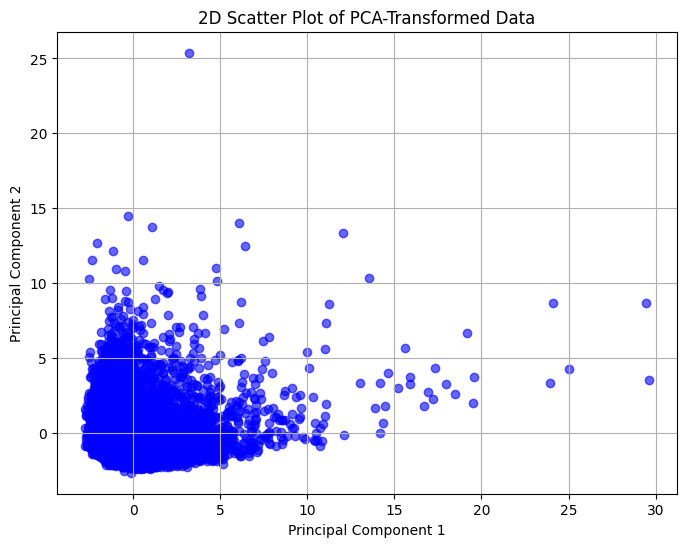

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c='blue', alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D Scatter Plot of PCA-Transformed Data')

plt.grid(True)
plt.show()


##Step 11 — Compute Covariance Matrix

In [ ]:
#Covariance Matrix only all features
#Compute covariance matrix (rows = features, so use rowvar=False)
cov_matrix_full = np.cov(X_scaled_df, rowvar=False)

cov_df_full = pd.DataFrame(cov_matrix_full, columns=X_scaled_df.columns)

cov_df_full.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,1.000112,0.322448,0.181281,0.164368,0.126483,0.496747,-0.077952,0.073174,-0.063193,0.449268,0.385195,0.154356,0.531326,0.322838,0.394326,-0.318995,0.072700
1,0.322448,1.000112,0.133689,0.104335,0.124306,0.099399,0.229741,0.202438,0.176099,0.191894,0.141571,0.189647,0.095805,0.065015,0.114262,-0.095093,0.119789
2,0.181281,0.133689,1.000112,0.916947,0.679972,-0.051480,0.393061,0.498485,0.315602,-0.120157,-0.067183,0.689638,0.356999,0.603331,0.093525,0.180399,0.086298
3,0.164368,0.104335,0.916947,1.000112,0.330658,-0.031329,0.264967,0.524950,0.127743,-0.082637,-0.046217,0.545584,0.319757,0.567355,0.048603,0.132778,0.064157
4,0.126483,0.124306,0.679972,0.330658,1.000112,-0.064251,0.442467,0.214066,0.511408,-0.132333,-0.074007,0.628178,0.256525,0.384127,0.131702,0.182590,0.086153


##Step 12 — Identify Features with Highest Covariance


In [ ]:
#Using all features
# Make a copy so we don't modify the original
cov_orig_df = cov_df_full.copy()
# Remove diagonal values by setting them to NaN
np.fill_diagonal(cov_orig_df.values, np.nan)

# Find the location (row, col) of the maximum covariance value
max_idx = np.unravel_index(np.nanargmax(cov_orig_df.values), cov_orig_df.shape)
var1 = cov_orig_df.columns[max_idx[0]]
var2 = cov_orig_df.columns[max_idx[1]]
max_cov_value = cov_orig_df.values[max_idx]

print('Strongest covariance pair:')
print(f'Variables: {var1} and {var2}')
print(f'Covariance value: {max_cov_value}')


Strongest covariance pair:
Variables: PURCHASES and ONEOFF_PURCHASES
Covariance value: 0.9169470108951336


## Step 13 — Determine Optimal Number of Clusters

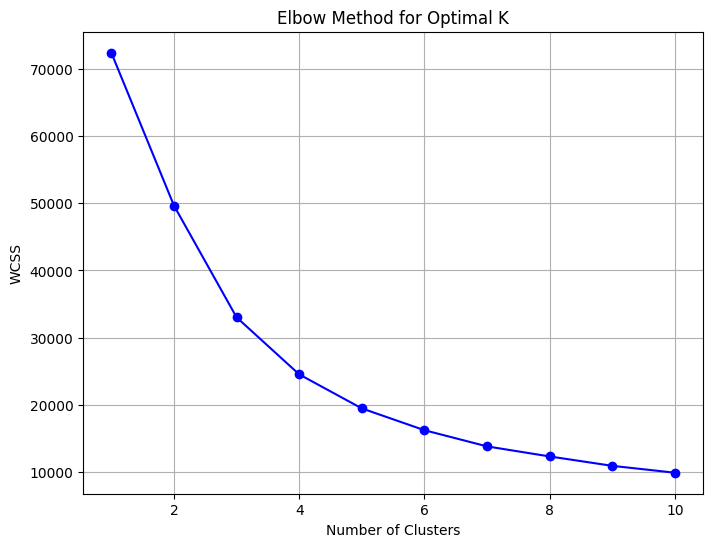

In [ ]:
#To Store WCSS (Within-Cluster Sum of Squares)
wcss = []

#Train K-Means models for multiple cluster values
# Try cluster values from 1 to 10
for k in range(1, 11):
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    model.fit(X_pca_2)   #fit the mode with feature matrix
    #Store WCSS
    wcss.append(model.inertia_)   # inertia_ = WCSS

#Use the Elbow Method to determine the ideal number of clusters.
#Plot the elbow graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='blue')

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()




## Step 14 — Apply K-Means Clustering

In [ ]:
#Choose optimal cluster count from elbow graph
ideal_k = 5
print('\nChosen number of clusters:', ideal_k)



Chosen number of clusters: 5


In [ ]:
#Train K-Means models for multiple cluster values
kmeans_final = KMeans(n_clusters=ideal_k, random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(X_pca_2)

pca_df['cluster'] = clusters
pca_df.head()


,PC1,PC2,cluster
0,-1.682220,-1.076451,1
1,-1.138295,2.506477,0
2,0.969684,-0.383520,4
3,-0.873628,0.043166,1
4,-1.599434,-0.688581,1


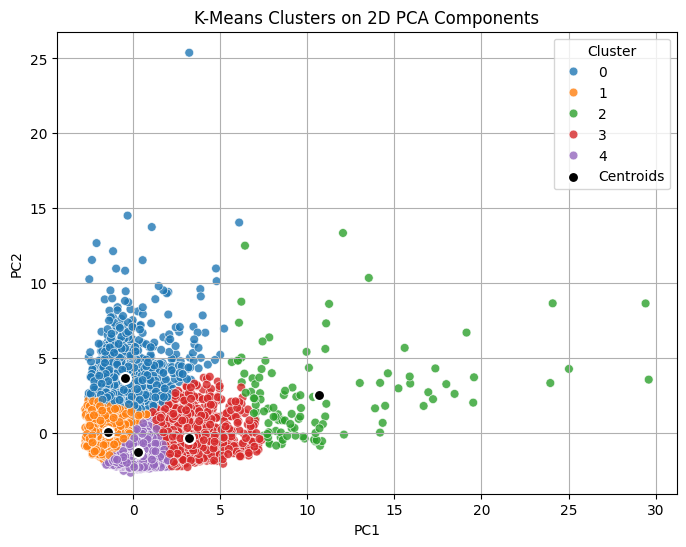

In [ ]:
#Visualize clustered customers in 2D PCA space.
#showing centroids
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    s=40,
    alpha=0.8
)

#Centroids are already in PCA space
#plot centroids
centroids = kmeans_final.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=250,
    c='black',
    marker='.',
    edgecolor='white',
    linewidth=1.5,
    label='Centroids'
)

plt.title('K-Means Clusters on 2D PCA Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()
